<a href="https://colab.research.google.com/github/Ebrardemir/amazon-sentiment-analysis/blob/main/notebooks/04_TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Duygu Analizi Model Eğitimi ve Karşılaştırma

Bu defterde, Amazon Datset Reviews 2023 üzerindne aldığımız Electronic kategorisi üzerinden metin verileri üzerinde duygu analizi yapıyoruz.Önceki defterlerde örneklem çıkarılıp ,veriseti üstünde analiz yapılıp ,ön işleme adımları yapılmıştır.Bu defterde ise metin verilerimiz TF-IDF ile vektörüze edilerek model eğitimine verilmiştir.

### Yapılan Adımlar:

1.  **Veri Yükleme ve Ön İşleme**: `amazon_reviews_preprocessed_FINAL.csv` adlı veri seti yüklenmiş, 'clean_text' ve 'clean_title' sütunlarındaki eksik değerler doldurulmuş ve boş metinler filtrelenmiştir.
2.  **Veri Bölme**: Veri seti, eğitim, doğrulama (validation) ve test setlerine stratifiye edilmiş şekilde ayrılmıştır.Veri seti test seti %15 validation seti %15 train seti %70 olacak şekilde ayrılmıştır.
3.  **TF-IDF Vektörizasyonu**: Hem başlık (title) hem de metin (text) sütunları için TF-IDF (Term Frequency-Inverse Document Frequency) vektörizasyonu uygulanmış, ardından bu vektörler birleştirilerek tek bir özellik matrisi oluşturulmuştur.
4.  **Model Eğitimi ve Değerlendirme**: Logistic Regression, Multinomial Naive Bayes, Linear SVM, XGBoost ve LightGBM gibi farklı sınıflandırma modelleri, birleştirilmiş TF-IDF matrisi üzerinde eğitilmiş ve her bir modelin performansı doğrulama ve test setlerinde ayrı ayrı değerlendirilmiştir.
5.  **Model Karşılaştırması**: Eğitilen modellerin performans metrikleri (Accuracy, Precision, Recall, F1-Score, ROC-AUC) bir karşılaştırma tablosunda sunulmuş ve görsellerle desteklenmiştir. ROC eğrileri de karşılaştırma için çizilmiştir.
6.  **Özellik Önem Analizi**: Logistic Regression modeli özelinde, en etkili pozitif ve negatif kelimeler belirlenerek görselleştirilmiştir.
7.  **Hata Analizi**: En iyi performans gösteren modelin yanlış sınıflandırdığı örnekler (False Positive ve False Negative) incelenmiştir.
8.  **Model Kaydetme ve Yeni Tahminler**: En iyi performansı gösteren model ve TF-IDF vektörleyicileri kaydedilmiş, ayrıca yeni yorumlar için duygu tahmini yapabilen bir fonksiyon örneği sunulmuştur.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import joblib

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


# Veri Seti Okuma
Kullanacağımız csv dosyasının ilk 5 satırı listelenerek csv dosyasının satır ve sütun bilgileri alınmıştır.

In [ ]:
input_path = '/content/drive/MyDrive/Veri_madenciliği/Dataset/amazon_reviews_preprocessed_FINAL.csv'

df = pd.read_csv(input_path)

print(f'Veri seti yüklendi: {df.shape[0]:,} satır, {df.shape[1]} sütun')
print(f'\nSütunlar: {df.columns.tolist()}')

display(df.head())

Veri seti yüklendi: 539,502 satır, 17 sütun

Sütunlar: ['main_category', 'parent_asin', 'user_id', 'title', 'text', 'timestamp', 'helpful_vote', 'verified_purchase', 'char_count', 'exclamation_count', 'question_count', 'uppercase_count', 'clean_title', 'clean_text', 'final_text_len', 'label', 'avg_word_len']


,main_category,parent_asin,user_id,title,text,timestamp,helpful_vote,verified_purchase,char_count,exclamation_count,question_count,uppercase_count,clean_title,clean_text,final_text_len,label,avg_word_len
0,AMAZON FASHION,B07C1JV4D6,AHFNZX5F56JGJB3YNWA57ZN4APXA,Decrease in quality,I previously purchased this band and wire it f...,1580012908597,0,True,0.090588,0.000000,0.0,5,decrease quality,previously purchased band wire 6 months straig...,146,0,0.074049
1,AMAZON FASHION,B07Y1WXKK7,AGKJS7CWFAIMUF3XSZBD2PLYWPJA,Sizing is poor,For slim nine year old the small was way too s...,1628407422155,0,True,0.040392,0.000000,0.0,3,sizing poor,slim nine year old small way small large way l...,75,0,0.058943
2,AMAZON FASHION,B0B5LM3BM4,AHPWHEPY6LTUH3GAB6B2CXAEJ5GQ,Band not as pictured,The band I recieved is NOT what was pictured. ...,1607109744225,0,True,0.040000,0.000000,0.0,6,band pictured,band recieved pictured got band narrow end ins...,57,0,0.053562
3,AMAZON FASHION,B07RM3SH7T,AGCXKLCXMUBUGFDY4EIE6FISFLWQ,Didn't come in color that was shown,Didn't come in color that was shown,1646075961857,0,True,0.009804,0.000000,0.0,1,didnt come color shown,didnt come color shown,22,0,0.060842
4,AMAZON FASHION,B093RXLDX3,AEMPA7MRAT4S6MZHV4W3GTBZVKRQ,Don’t buy,They do not work! You can not get the one side...,1675717611577,0,True,0.068627,0.038961,0.0,5,dont buy,work get one side band strap holders buckle wa...,91,0,0.052652


### Boş Metin ve Başlık Temizliği

Model eğitimi sırasında, yorumun kendisi (`clean_text`) veya başlığı (`clean_title`) tamamen boş olan kayıtların kullanılması, modelin öğrenme sürecini olumsuz etkileyebilir. Bu tür boş girişler, anlamsız özellikler üretir ve modelin doğru desenleri yakalamasını zorlaştırır.

Bu nedenle, veri setinden hem metin hem de başlık alanları tamamen boş olan satırların çıkarılması, modelin daha kaliteli ve anlamlı verilerle eğitilmesini sağlayarak performansını artırır. Bu, gürültüyü azaltır ve modelin gerçek duygu sinyallerine odaklanmasına yardımcı olur.

In [ ]:

print(' ETİKET DAĞILIMI \n')
print('Sayısal:')
print(df['label'].value_counts())
print('\nYüzdesel:')
print((df['label'].value_counts(normalize=True) * 100).round(2))

# clean_text ve clean_title'ı temizle
df['clean_text'] = df['clean_text'].fillna('').astype(str)
df['clean_title'] = df['clean_title'].fillna('').astype(str)

# Hem text hem title boş olan satırları at
df = df[(df['clean_text'].str.strip() != '') | (df['clean_title'].str.strip() != '')].reset_index(drop=True)

print(f'\nBoş metinler temizlendikten sonra: {len(df):,} satır')


print(f'\nBoş title sayısı  : {(df["clean_title"].str.strip() == "").sum():,}')
print(f'Boş text sayısı   : {(df["clean_text"].str.strip() == "").sum():,}')
print(f'\nOrtalama title uzunluğu: {df["clean_title"].str.len().mean():.1f} karakter')
print(f'Ortalama text uzunluğu : {df["clean_text"].str.len().mean():.1f} karakter')

 ETİKET DAĞILIMI 

Sayısal:
label
1    276974
0    262528
Name: count, dtype: int64

Yüzdesel:
label
1    51.34
0    48.66
Name: proportion, dtype: float64

Boş metinler temizlendikten sonra: 539,502 satır

Boş title sayısı  : 1,721
Boş text sayısı   : 0

Ortalama title uzunluğu: 18.6 karakter
Ortalama text uzunluğu : 158.1 karakter


# Veri Setinin Bölünmesi (Train-Val-Test Split)
Modelin ezberlemesini önlemek ve doğru değerlendirilmesini sağlamak amacıyla veri seti üç alt kümeye ayrılmıştır. Veri bütünlüğünü korumak için bölme işlemi doğrudan veriler yerine DataFrame indeksleri karıştırılarak yapılmıştır. Böylece her bir yoruma ait başlık, içerik ve hedef etiket (0/1) arasındaki hizalama kusursuz şekilde korunmuştur.

Aşamalar:

Test Setinin Ayrılması: Tüm indekslerin %15'i, sınıf dağılımları korunarak (stratify) test seti olarak ayrılmıştır.

Eğitim ve Doğrulama (Validation) Setlerinin Ayrılması: Geriye kalan %85'lik geçici veri üzerinden ikinci bir bölme işlemi yapılmıştır. Toplam veri setinde %15'lik bir paya ulaşmak amacıyla, bu geçici setin %17.65'i Doğrulama (Validation) seti olarak belirlenmiş, geri kalan veriler ise Eğitim (Train) seti olarak bırakılmıştır.

Dağılım: %70 Eğitim, %15 Doğrulama ve %15 Test şeklindedir.

In [ ]:
# Hedef değişken
y = df['label']


indeksler = df.index

# Test seti %15 olacak Şekilde ayırılıyor.
idx_temp, idx_test = train_test_split(
    indeksler, test_size=0.15, stratify=y, random_state=42
)

# Train seti (%70) ve Validation seti (%15)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=0.1765, stratify=y.loc[idx_temp], random_state=42
)

# Title için veri ayrımı yapılıyor
X_train_title = df.loc[idx_train, 'clean_title']
X_val_title   = df.loc[idx_val,   'clean_title']
X_test_title  = df.loc[idx_test,  'clean_title']

# Text için veri ayrımı yapılıyor.
X_train_text = df.loc[idx_train, 'clean_text']
X_val_text   = df.loc[idx_val,   'clean_text']
X_test_text  = df.loc[idx_test,  'clean_text']


y_train = y.loc[idx_train]
y_val   = y.loc[idx_val]
y_test  = y.loc[idx_test]

toplam = len(df)
print(' VERİ BÖLÜNDÜ \n')
print(f'Train seti      : {len(idx_train):,} yorum ({len(idx_train)/toplam*100:.1f}%)')
print(f'Validation seti : {len(idx_val):,} yorum ({len(idx_val)/toplam*100:.1f}%)')
print(f'Test seti       : {len(idx_test):,} yorum ({len(idx_test)/toplam*100:.1f}%)')
print(f'Toplam          : {toplam:,} yorum')

print('\nTrain etiket dağılımı:')
print(y_train.value_counts(normalize=True).round(3))
print('\nValidation etiket dağılımı:')
print(y_val.value_counts(normalize=True).round(3))
print('\nTest etiket dağılımı:')
print(y_test.value_counts(normalize=True).round(3))

 VERİ BÖLÜNDÜ 

Train seti      : 377,637 yorum (70.0%)
Validation seti : 80,939 yorum (15.0%)
Test seti       : 80,926 yorum (15.0%)
Toplam          : 539,502 yorum

Train etiket dağılımı:
label
1    0.513
0    0.487
Name: proportion, dtype: float64

Validation etiket dağılımı:
label
1    0.513
0    0.487
Name: proportion, dtype: float64

Test etiket dağılımı:
label
1    0.513
0    0.487
Name: proportion, dtype: float64


 ### TF-IDF Vektörizasyonu ve Özellik Birleştirme
 Bu hücrede, modelin metinleri matematiksel olarak işleyebilmesi için **TF-IDF** yöntemi uygulanmış ve şu adımlar izlenmiştir:
* **Metinlerin Sayısallaştırılması:** Başlık (`title`) ve metin (`text`) verileri ayrı ayrı işlenmiştir. Bağlamı yakalamak için kelimeler tekli, ikili ve üçlü gruplar (`ngram_range=(1,3)`) halinde değerlendirilmiş; aşırı nadir veya çok sık geçen kelimeler kirlilik yaratmaması için elenmiştir.
 * **Kapasite Belirleme:** Bellek ve işlemci optimizasyonu için Başlıklardan en önemli **5.000**, Metinlerden ise **20.000** özellik (feature) seçilmiştir.
 * **Veri Sızıntısının (Data Leakage) Önlenmesi:** Modelin test verisini ezberlememesi için kelime sözlüğü **sadece** Eğitim (Train) seti kullanılarak oluşturulmuş (`fit_transform`); Validation ve Test setleri bu sözlüğe göre dönüştürülmüştür (`transform`).
 * **Matrislerin Birleştirilmesi (`hstack`):** Oluşturulan 5.000 sütunluk başlık ve 20.000 sütunluk metin matrisleri yan yana eklenerek modelin öğreneceği toplam **25.000 özellikli** nihai matris elde edilmiştir. Bu devasa tablo, RAM'i şişirmemesi için CSR formatında sıkıştırılarak kullanıma hazır hale getirilmiştir.


In [ ]:
print('TF-IDF vektörizasyonu başladı.\n')

#  TITLE TF-IDF
tfidf_title = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=10,
    max_df=0.95,
    max_features=5000,
    sublinear_tf=True
)

start = time.time()
X_train_title_tfidf = tfidf_title.fit_transform(X_train_title)
X_val_title_tfidf   = tfidf_title.transform(X_val_title)
X_test_title_tfidf  = tfidf_title.transform(X_test_title)
print(f'Title TF-IDF tamamlandı ({time.time()-start:.1f} sn)')
print(f'  Train shape: {X_train_title_tfidf.shape}')
print(f'  Sözlük boyutu: {len(tfidf_title.vocabulary_):,}')

#  TEXT TF-IDF
tfidf_text = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=10,
    max_df=0.95,
    max_features=20000,
    sublinear_tf=True
)

start = time.time()
X_train_text_tfidf = tfidf_text.fit_transform(X_train_text)
X_val_text_tfidf   = tfidf_text.transform(X_val_text)
X_test_text_tfidf  = tfidf_text.transform(X_test_text)
print(f'\nText TF-IDF tamamlandı ({time.time()-start:.1f} sn)')
print(f'  Train shape: {X_train_text_tfidf.shape}')
print(f'  Sözlük boyutu: {len(tfidf_text.vocabulary_):,}')

#  HSTACK: Title + Text yan yana birleştir
X_train_combined = hstack([X_train_title_tfidf, X_train_text_tfidf]).tocsr()
X_val_combined   = hstack([X_val_title_tfidf,   X_val_text_tfidf]).tocsr()
X_test_combined  = hstack([X_test_title_tfidf,  X_test_text_tfidf]).tocsr()

print(f'\n BİRLEŞİK MATRİS ')
print(f'Train: {X_train_combined.shape}')
print(f'Val  : {X_val_combined.shape}')
print(f'Test : {X_test_combined.shape}')
print(f'Toplam feature sayısı: {X_train_combined.shape[1]:,}')

TF-IDF vektörizasyonu başladı.

Title TF-IDF tamamlandı (10.3 sn)
  Train shape: (377637, 5000)
  Sözlük boyutu: 5,000

Text TF-IDF tamamlandı (131.4 sn)
  Train shape: (377637, 20000)
  Sözlük boyutu: 20,000

 BİRLEŞİK MATRİS 
Train: (377637, 25000)
Val  : (80939, 25000)
Test : (80926, 25000)
Toplam feature sayısı: 25,000


In [ ]:
# Title ve Text için en yüksek IDF skorlu Terimler Listelenir
print(' TITLE - En Yüksek IDF (En Nadir) 15 Terim')
title_idf = pd.DataFrame({
    'term': tfidf_title.get_feature_names_out(),
    'idf': tfidf_title.idf_
}).sort_values('idf', ascending=False)
display(title_idf.head(15))

print('\n TEXT - En Yüksek IDF (En Nadir) 15 Terim ')
text_idf = pd.DataFrame({
    'term': tfidf_text.get_feature_names_out(),
    'idf': tfidf_text.idf_
}).sort_values('idf', ascending=False)
display(text_idf.head(15))

# Trigram örnekleri
print('\n TEXT - Trigram (3-gram) Örnekleri ')
trigrams = [t for t in tfidf_text.get_feature_names_out() if len(t.split()) == 3]
print(f'Toplam trigram sayısı: {len(trigrams):,}')
print('İlk 20 trigram örneği:')
for tg in trigrams[:20]:
    print(f'  - {tg}')

 TITLE - En Yüksek IDF (En Nadir) 15 Terim


,term,idf
2451,junk junk,10.545854
142,ads,10.545854
2797,malo,10.509487
3010,news,10.474396
3779,riding,10.474396
3109,ohm,10.474396
3351,polarity,10.474396
1409,esperaba,10.474396
1406,es muy,10.474396
554,bs,10.474396



 TEXT - En Yüksek IDF (En Nadir) 15 Terim 


,term,idf
9103,keystones,10.315331
16062,squish,10.258172
6668,furrion,10.230773
9025,junk junk,10.230773
6738,gels,10.204105
19064,wink,10.204105
10263,lowepro,10.152812
1927,blah,10.128119
4575,digitizer,10.128119
10876,moko,10.128119



 TEXT - Trigram (3-gram) Örnekleri 
Toplam trigram sayısı: 711
İlk 20 trigram örneği:
  - 10 feet away
  - 10 year old
  - 11 year old
  - 12 year old
  - 30 day return
  - 90 day warranty
  - able get work
  - almost impossible get
  - already stopped working
  - amazon customer service
  - appears well made
  - apple car play
  - band came fitbit
  - battery doesnt last
  - battery fully charged
  - battery last long
  - battery lasts long
  - battery life good
  - battery life great
  - best bang buck


# Model Eğitim ve Değerlendirme Fonksiyonu
 Farklı makine öğrenmesi modellerini denerken kod tekrarını önlemek ve süreci standartlaştırmak amacıyla bu otomatik test fonksiyonu hazırlanmıştır.
> Fonksiyona gönderilen her model için sırasıyla şu işlemler gerçekleştirilir:
> * **Eğitim (Training) ve Süre Ölçümü:** Model, Eğitim setiyle eğitilir ve bu işlemin hız/maliyet analizi için kaç saniye sürdüğü kaydedilir.
> * **Performans Metriklerinin Hesaplanması:** Modelin Doğrulama (Validation) ve Test setlerindeki başarısı; *Accuracy (Doğruluk), Precision (Kesinlik), Recall (Duyarlılık), F1-Score* ve *ROC-AUC* metrikleriyle ayrı ayrı ölçülür.
> * **Raporlama ve Görselleştirme:** Sınıflar bazında (Pozitif/Negatif) detaylı hata analizi yapabilmek için **Sınıflandırma Raporu (Classification Report)** yazdırılır ve modelin nerelerde yanıldığını görmek için **Karmaşıklık Matrisi (Confusion Matrix)** ısı haritası olarak çizdirilir.
> * **Sonuçların Kaydedilmesi:** Elde edilen tüm metrikler ve süre bilgileri paketlenerek (dictionary formatında) dışarı aktarılır. Bu sayede projenin sonunda denenen tüm modeller tek bir veri çerçevesinde (DataFrame) kolayca karşılaştırılabilecektir.
>
>

In [ ]:
def model_egit_ve_degerlendir(model, model_adi, X_train, y_train, X_val, y_val, X_test, y_test):

    print(f'\n{"="*70}')
    print(f' MODEL: {model_adi}')
    print(f'{"="*70}')

    #  Eğitim
    start = time.time()
    model.fit(X_train, y_train)
    egitim_suresi = time.time() - start
    print(f'Eğitim süresi: {egitim_suresi:.2f} saniye')

    #  (val + test)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    #  Olasılık skorları (ROC için)
    if hasattr(model, 'predict_proba'):
        y_val_score = model.predict_proba(X_val)[:, 1]
        y_test_score = model.predict_proba(X_test)[:, 1]
    else:
        y_val_score = model.decision_function(X_val)
        y_test_score = model.decision_function(X_test)

    #  VALIDATION SETİ METRİKLERİ
    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred)
    val_rec = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_auc = roc_auc_score(y_val, y_val_score)

    print(f'\n VALIDATION SETİ METRİKLERİ ')
    print(f'Accuracy : {val_acc:.4f}')
    print(f'Precision: {val_prec:.4f}')
    print(f'Recall   : {val_rec:.4f}')
    print(f'F1-Score : {val_f1:.4f}')
    print(f'ROC-AUC  : {val_auc:.4f}')

    #  TEST SETİ METRİKLERİ
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred)
    test_rec = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_score)

    print(f'\n TEST SETİ METRİKLERİ ')
    print(f'Accuracy : {test_acc:.4f}')
    print(f'Precision: {test_prec:.4f}')
    print(f'Recall   : {test_rec:.4f}')
    print(f'F1-Score : {test_f1:.4f}')
    print(f'ROC-AUC  : {test_auc:.4f}')


    print(f'\n TEST SETİ SINIFLANDIRMA RAPORU ')
    print(classification_report(y_test, y_test_pred, target_names=['Negatif (0)', 'Pozitif (1)']))

    # Test seti için confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['Negatif', 'Pozitif'],
        yticklabels=['Negatif', 'Pozitif']
    )
    plt.title(f'{model_adi} - Test Seti Confusion Matrix')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin Edilen Etiket')
    plt.tight_layout()
    plt.show()

    return {
        'model': model,
        'model_adi': model_adi,
        # Validation metrikleri
        'val_accuracy': val_acc,
        'val_precision': val_prec,
        'val_recall': val_rec,
        'val_f1': val_f1,
        'val_roc_auc': val_auc,
        # Test metrikleri
        'test_accuracy': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1,
        'test_roc_auc': test_auc,
        # Zaman + tahminler
        'egitim_suresi': egitim_suresi,
        'y_test_pred': y_test_pred,
        'y_test_score': y_test_score
    }


tum_sonuclar = []

Logistic Regresyon ile Model Eğitimi


 MODEL: Logistic Regression
Eğitim süresi: 14.41 saniye

 VALIDATION SETİ METRİKLERİ 
Accuracy : 0.9155
Precision: 0.9181
Recall   : 0.9172
F1-Score : 0.9176
ROC-AUC  : 0.9730

 TEST SETİ METRİKLERİ 
Accuracy : 0.9160
Precision: 0.9194
Recall   : 0.9167
F1-Score : 0.9181
ROC-AUC  : 0.9728

 TEST SETİ SINIFLANDIRMA RAPORU 
              precision    recall  f1-score   support

 Negatif (0)       0.91      0.92      0.91     39380
 Pozitif (1)       0.92      0.92      0.92     41546

    accuracy                           0.92     80926
   macro avg       0.92      0.92      0.92     80926
weighted avg       0.92      0.92      0.92     80926



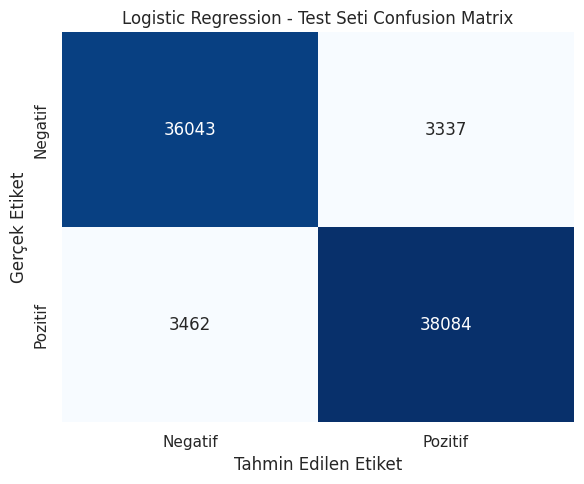

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='liblinear',
    random_state=42
)

sonuc_lr = model_egit_ve_degerlendir(
    lr_model, 'Logistic Regression',
    X_train_combined, y_train,
    X_val_combined, y_val,
    X_test_combined, y_test
)
tum_sonuclar.append(sonuc_lr)

Naive Bayes ile Model Eğitimi


 MODEL: Multinomial Naive Bayes
Eğitim süresi: 0.11 saniye

 VALIDATION SETİ METRİKLERİ 
Accuracy : 0.9013
Precision: 0.9003
Recall   : 0.9085
F1-Score : 0.9044
ROC-AUC  : 0.9643

 TEST SETİ METRİKLERİ 
Accuracy : 0.8995
Precision: 0.8979
Recall   : 0.9073
F1-Score : 0.9026
ROC-AUC  : 0.9637

 TEST SETİ SINIFLANDIRMA RAPORU 
              precision    recall  f1-score   support

 Negatif (0)       0.90      0.89      0.90     39380
 Pozitif (1)       0.90      0.91      0.90     41546

    accuracy                           0.90     80926
   macro avg       0.90      0.90      0.90     80926
weighted avg       0.90      0.90      0.90     80926



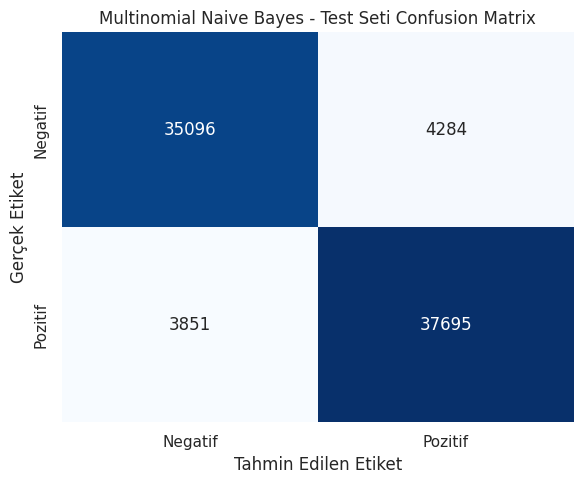

In [ ]:
nb_model = MultinomialNB(alpha=1.0)

sonuc_nb = model_egit_ve_degerlendir(
    nb_model, 'Multinomial Naive Bayes',
    X_train_combined, y_train,
    X_val_combined, y_val,
    X_test_combined, y_test
)
tum_sonuclar.append(sonuc_nb)

Lİnear SVC ile Model Eğitimi


 MODEL: Linear SVM
Eğitim süresi: 25.96 saniye

 VALIDATION SETİ METRİKLERİ 
Accuracy : 0.9129
Precision: 0.9157
Recall   : 0.9146
F1-Score : 0.9151
ROC-AUC  : 0.9716

 TEST SETİ METRİKLERİ 
Accuracy : 0.9122
Precision: 0.9157
Recall   : 0.9131
F1-Score : 0.9144
ROC-AUC  : 0.9709

 TEST SETİ SINIFLANDIRMA RAPORU 
              precision    recall  f1-score   support

 Negatif (0)       0.91      0.91      0.91     39380
 Pozitif (1)       0.92      0.91      0.91     41546

    accuracy                           0.91     80926
   macro avg       0.91      0.91      0.91     80926
weighted avg       0.91      0.91      0.91     80926



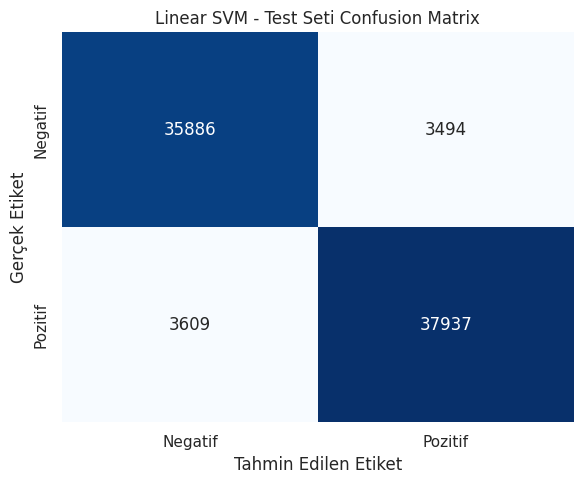

In [ ]:
svm_model = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=42
)

sonuc_svm = model_egit_ve_degerlendir(
    svm_model, 'Linear SVM',
    X_train_combined, y_train,
    X_val_combined, y_val,
    X_test_combined, y_test
)
tum_sonuclar.append(sonuc_svm)

XGBoost ile Model Eğitimi

XGBoost versiyonu: 3.2.0

 MODEL: XGBoost
Eğitim süresi: 1008.34 saniye

 VALIDATION SETİ METRİKLERİ 
Accuracy : 0.8747
Precision: 0.8896
Recall   : 0.8630
F1-Score : 0.8761
ROC-AUC  : 0.9499

 TEST SETİ METRİKLERİ 
Accuracy : 0.8751
Precision: 0.8908
Recall   : 0.8623
F1-Score : 0.8764
ROC-AUC  : 0.9494

 TEST SETİ SINIFLANDIRMA RAPORU 
              precision    recall  f1-score   support

 Negatif (0)       0.86      0.89      0.87     39380
 Pozitif (1)       0.89      0.86      0.88     41546

    accuracy                           0.88     80926
   macro avg       0.88      0.88      0.88     80926
weighted avg       0.88      0.88      0.88     80926



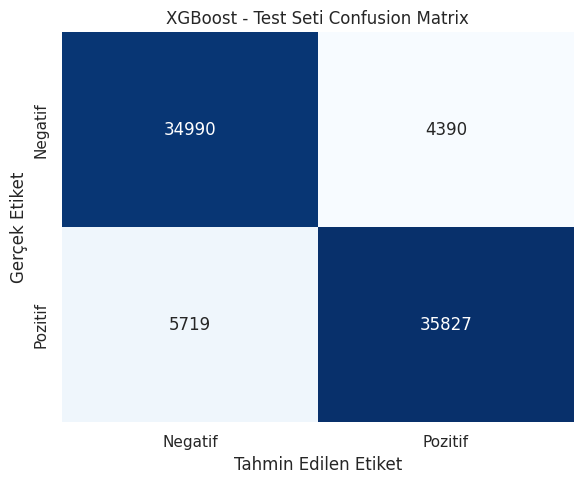

In [ ]:
# XGBoost yüklemesi
!pip install -q xgboost

import xgboost as xgb
print(f'XGBoost versiyonu: {xgb.__version__}')

# GPU yerine CPU kullan (TF-IDF sparse veride GPU bug riski)
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',     # GPU yerine CPU hist
    device='cpu',           # ← GPU'yu kapat
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

sonuc_xgb = model_egit_ve_degerlendir(
    xgb_model, 'XGBoost',
    X_train_combined, y_train,
    X_val_combined, y_val,
    X_test_combined, y_test
)
tum_sonuclar.append(sonuc_xgb)

LİghtGBM ile Model Eğitimi

LightGBM versiyonu: 4.6.0

 MODEL: LightGBM
Eğitim süresi: 1160.97 saniye

 VALIDATION SETİ METRİKLERİ 
Accuracy : 0.9048
Precision: 0.9054
Recall   : 0.9095
F1-Score : 0.9075
ROC-AUC  : 0.9683

 TEST SETİ METRİKLERİ 
Accuracy : 0.9059
Precision: 0.9059
Recall   : 0.9113
F1-Score : 0.9086
ROC-AUC  : 0.9680

 TEST SETİ SINIFLANDIRMA RAPORU 
              precision    recall  f1-score   support

 Negatif (0)       0.91      0.90      0.90     39380
 Pozitif (1)       0.91      0.91      0.91     41546

    accuracy                           0.91     80926
   macro avg       0.91      0.91      0.91     80926
weighted avg       0.91      0.91      0.91     80926



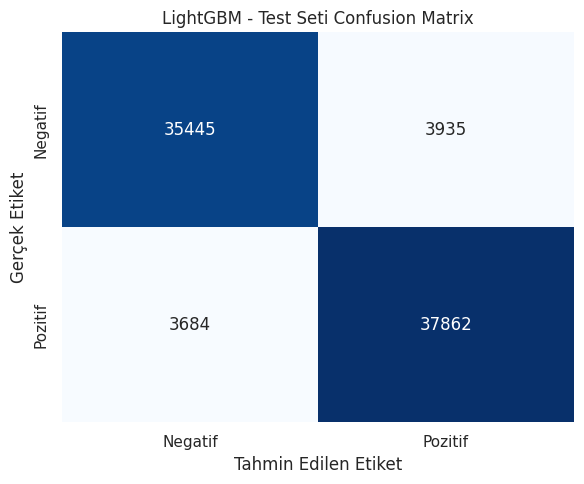

In [ ]:
!pip install -q lightgbm

import lightgbm as lgb
print(f'LightGBM versiyonu: {lgb.__version__}')

lgb_model = lgb.LGBMClassifier(
    n_estimators=300, num_leaves=63, learning_rate=0.1,
    objective='binary', metric='binary_logloss',
    random_state=42, n_jobs=-1, verbose=-1
)

sonuc_lgb = model_egit_ve_degerlendir(
    lgb_model, 'LightGBM',
    X_train_combined, y_train,
    X_val_combined, y_val,
    X_test_combined, y_test
)
tum_sonuclar.append(sonuc_lgb)

# Model Karşılaştırma
Eğitilen 5 model bir tabloda karşılaştırma işlemi yapılır.

In [ ]:

karsilastirma_df = pd.DataFrame([
    {
        'Model': s['model_adi'],
        'Val Accuracy': round(s['val_accuracy'], 4),
        'Val F1': round(s['val_f1'], 4),
        'Val ROC-AUC': round(s['val_roc_auc'], 4),
        'Test Accuracy': round(s['test_accuracy'], 4),
        'Test Precision': round(s['test_precision'], 4),
        'Test Recall': round(s['test_recall'], 4),
        'Test F1': round(s['test_f1'], 4),
        'Test ROC-AUC': round(s['test_roc_auc'], 4),
        'Eğitim Süresi (sn)': round(s['egitim_suresi'], 2)
    }
    for s in tum_sonuclar
]).sort_values('Test F1', ascending=False).reset_index(drop=True)

print(' MODEL KARŞILAŞTIRMA TABLOSU \n')
display(karsilastirma_df)

# CSV olarak kaydet
output_dir = '/content/drive/MyDrive/Veri_madenciliği/Sonuclar/'
os.makedirs(output_dir, exist_ok=True)
karsilastirma_df.to_csv(output_dir + '04A_title_text_karsilastirma.csv', index=False, encoding='utf-8-sig')
print(f'\nTablo kaydedildi: {output_dir}04A_title_text_karsilastirma.csv')

 MODEL KARŞILAŞTIRMA TABLOSU 



,Model,Val Accuracy,Val F1,Val ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Eğitim Süresi (sn)
0,Logistic Regression,0.9155,0.9176,0.9730,0.9160,0.9194,0.9167,0.9181,0.9728,14.41
1,Linear SVM,0.9129,0.9151,0.9716,0.9122,0.9157,0.9131,0.9144,0.9709,25.96
2,LightGBM,0.9048,0.9075,0.9683,0.9059,0.9059,0.9113,0.9086,0.9680,1160.97
3,Multinomial Naive Bayes,0.9013,0.9044,0.9643,0.8995,0.8979,0.9073,0.9026,0.9637,0.11
4,XGBoost,0.8747,0.8761,0.9499,0.8751,0.8908,0.8623,0.8764,0.9494,1008.34



Tablo kaydedildi: /content/drive/MyDrive/Veri_madenciliği/Sonuclar/04A_title_text_karsilastirma.csv


 # Model Performanslarının Görselleştirilmesi ve Karşılaştırması

> Bu hücrede, eğitilen tüm modellerin performans metrikleri (Accuracy, F1-Score, ROC-AUC) yan yana çubuk grafikler (bar chart) halinde görselleştirilmiştir.
> * **İkili Görünüm (Validation vs Test):** Sol tarafta modellerin **Validation (Doğrulama)** skorları, sağ tarafta ise **Test** skorları konumlandırılmıştır. Bu dizilim, modellerin hiç görmediği verilerdeki başarısını kıyaslamanın yanı sıra, aşırı öğrenme (overfitting) yapıp yapmadıklarını tek bakışta analiz etmemizi sağlar.
> * **Metriklerin Kıyaslanması:** Her model için Accuracy, F1 ve ROC-AUC değerleri farklı renkli çubuklarla gösterilerek modellerin hem genel doğruluğu hem de sınıflandırma kalitesi karşılaştırılmıştır.
> * **Dışa Aktarma:** Oluşturulan nihai grafik, proje raporu veya sunumlarda kullanılmaya hazır olacak şekilde yüksek çözünürlüklü bir PNG dosyası olarak kaydedilir.
>
>

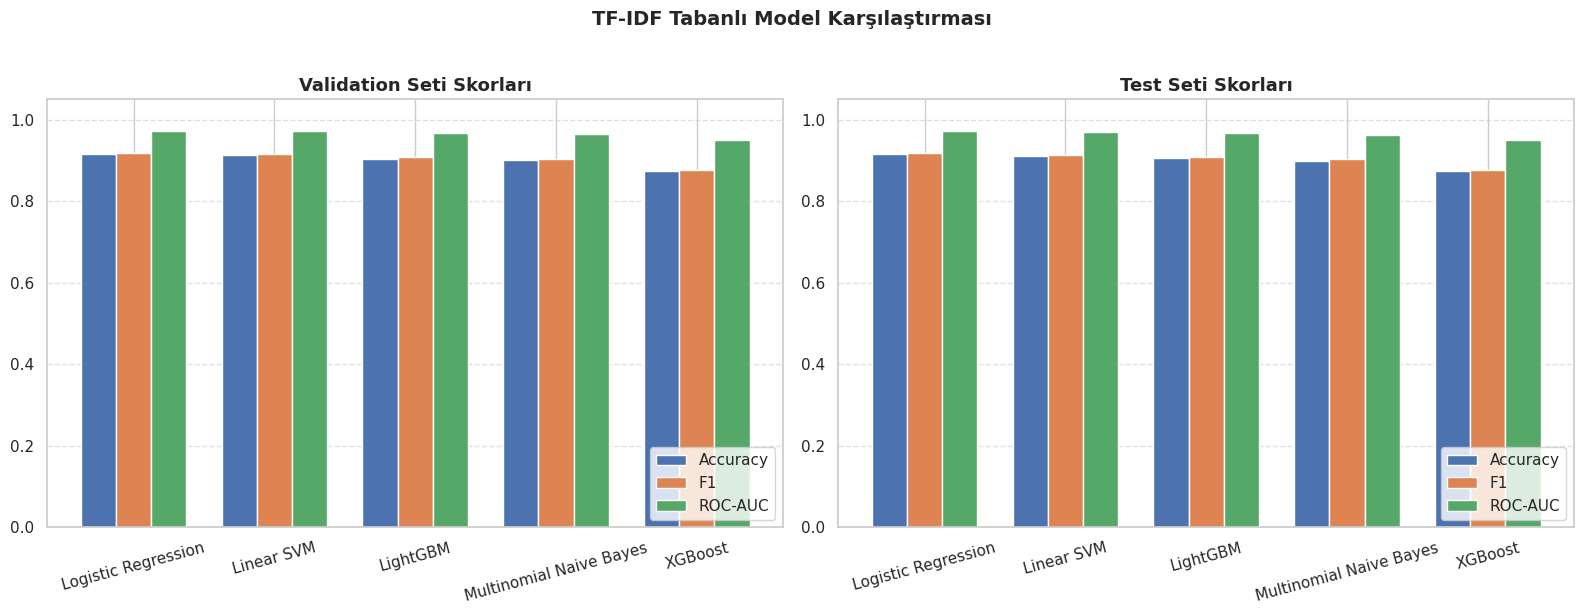

Grafik kaydedildi: /content/drive/MyDrive/Veri_madenciliği/Sonuclar/tfidf_model_karsilastirma.png


In [ ]:
# Validation vs Test karşılaştırma grafiği
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrikler = ['Accuracy', 'F1', 'ROC-AUC']
x = np.arange(len(karsilastirma_df))
width = 0.25

# Sol grafik: Validation skorları
for i, m in enumerate(metrikler):
    axes[0].bar(x + i * width, karsilastirma_df[f'Val {m}'], width, label=m)
axes[0].set_title('Validation Seti Skorları', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(karsilastirma_df['Model'], rotation=15)
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Sağ grafik: Test skorları
for i, m in enumerate(metrikler):
    axes[1].bar(x + i * width, karsilastirma_df[f'Test {m}'], width, label=m)
axes[1].set_title('Test Seti Skorları', fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(karsilastirma_df['Model'], rotation=15)
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('TF-IDF Tabanlı Model Karşılaştırması', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_dir + 'tfidf_model_karsilastirma.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Grafik kaydedildi: {output_dir}tfidf_model_karsilastirma.png')

# ROC Eğrileri (ROC Curve) Karşılaştırması

> Bu hücrede, eğitilen tüm modellerin sınıflandırma performansları **ROC Eğrisi (Receiver Operating Characteristic)** kullanılarak tek bir grafik üzerinde karşılaştırılmıştır.
> * **Eğrinin Anlamı:** ROC eğrisi, modelin Doğru Pozitif Oranı (TPR) ile Yanlış Pozitif Oranı (FPR) arasındaki dengeyi gösterir. Bir eğri sol üst köşeye ne kadar yakınsa, modelin ayırt edicilik gücü o kadar yüksektir.
> * **AUC Skoru:** Lejantta belirtilen AUC (Area Under Curve) değeri, eğrinin altında kalan alanı temsil eder. Rastgele tahmin yapan bir modelin AUC skoru 0.5'tir (siyah kesik çizgi). Modellerimizin AUC skorunun 1.0'a ne kadar yakın olduğu, başarısını doğrudan yansıtır.
> * Tüm modellerin sonuçları üst üste bindirilerek, test verisi üzerinde en iyi ayrımı yapan algoritma görsel olarak tespit edilmiş ve grafik raporlama için dışa aktarılmıştır.
>
>

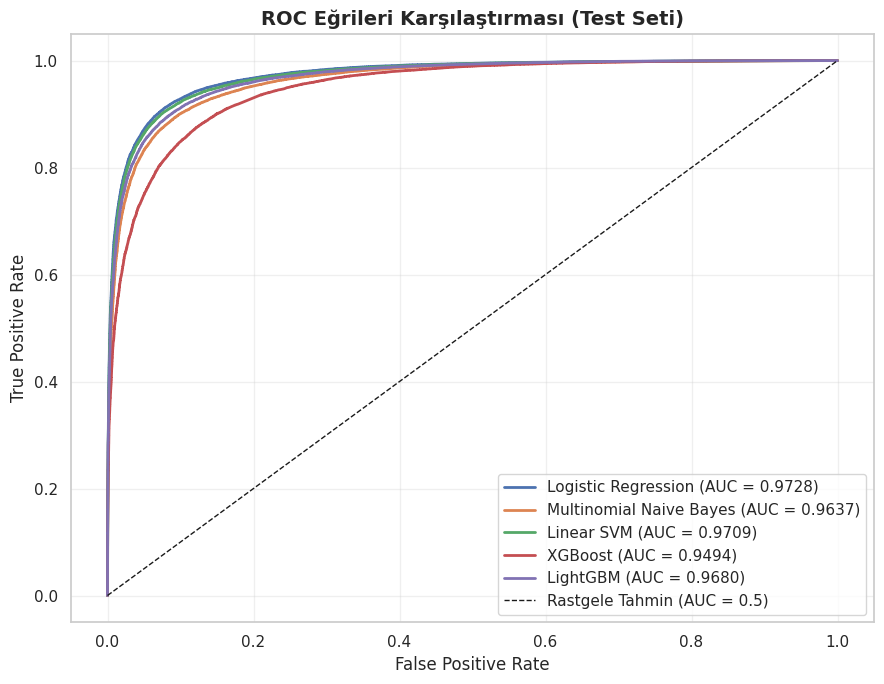

In [ ]:
plt.figure(figsize=(9, 7))

for sonuc in tum_sonuclar:
    fpr, tpr, _ = roc_curve(y_test, sonuc['y_test_score'])
    plt.plot(fpr, tpr, lw=2,
             label=f"{sonuc['model_adi']} (AUC = {sonuc['test_roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele Tahmin (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Eğrileri Karşılaştırması (Test Seti)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir + '04A_title_text_roc.png', dpi=200, bbox_inches='tight')
plt.show()

# Modelin Karar Mekanizmasının Analizi (Özellik Önem Dereceleri)
Bu hücrede, Lojistik Regresyon modelinin tahmin yaparken hangi kelimelere odaklandığı (Feature Importance) incelenmiştir.

Doğrusal modeller, eğitim sırasında her kelimeye (veya n-gram'a) pozitif veya negatif bir matematiksel katsayı (ağırlık) atar. Pozitif katsayısı en yüksek olan kelimeler modeli "Olumlu (1)" sınıfına, en düşük (negatif) olanlar ise "Olumsuz (0)" sınıfına yönlendirir.

Kod içerisinde Başlık (Title) ve Metin (Text) sözlükleri uç uca eklenmiş (np.concatenate), modelin katsayıları (coef_) ile eşleştirilmiş ve modelin kararlarını en çok etkileyen Top 20 Pozitif ve Top 20 Negatif kelime grupları çıkarılarak modelin şeffaflığı (explainability) test edilmiştir.

In [ ]:
def en_etkili_kelimeler(model, feature_names_list, top_n=20):

    # feature_names = vectorizer.get_feature_names_out() # Removed this line
    coefs = model.coef_[0]

    df_coefs = pd.DataFrame({'kelime': feature_names_list, 'katsayi': coefs})

    en_pozitif = df_coefs.nlargest(top_n, 'katsayi').reset_index(drop=True)
    en_negatif = df_coefs.nsmallest(top_n, 'katsayi').reset_index(drop=True)

    return en_pozitif, en_negatif

# Combine feature names from both TF-IDF vectorizers
combined_feature_names = np.concatenate([tfidf_title.get_feature_names_out(), tfidf_text.get_feature_names_out()])

# Logistic Regression'dan çıkar
pos_words, neg_words = en_etkili_kelimeler(sonuc_lr['model'], combined_feature_names, top_n=20)

print(' EN POZİTİF 20 KELİME (Logistic Regression) ')
display(pos_words)

print('\n EN NEGATİF 20 KELİME (Logistic Regression) ')
display(neg_words)

 EN POZİTİF 20 KELİME (Logistic Regression) 


,kelime,katsayi
0,great,9.881816
1,love,8.748030
2,perfect,8.371369
3,complaint,7.532611
4,excellent,7.263489
5,perfectly,6.411250
6,loves,5.992137
7,four stars,5.867628
8,amazing,5.670327
9,nice,5.444037



 EN NEGATİF 20 KELİME (Logistic Regression) 


,kelime,katsayi
0,returning,-8.216462
1,two stars,-8.064509
2,disappointed,-7.772252
3,returned,-7.578472
4,useless,-7.514973
5,two stars,-7.409120
6,one star,-7.009078
7,return,-6.936154
8,disappointing,-6.801189
9,poor,-6.734134


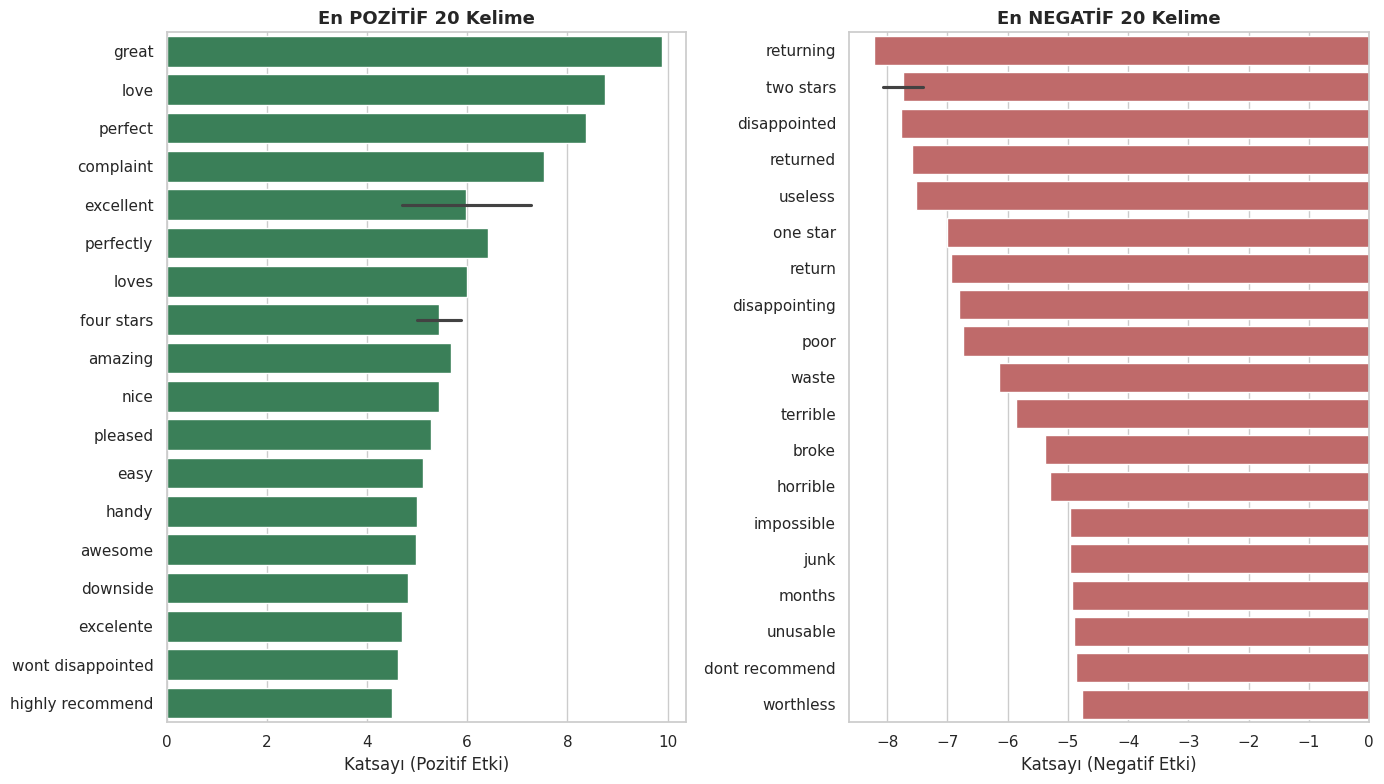

In [ ]:
# Görselleştirme: yan yana iki bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.barplot(data=pos_words, y='kelime', x='katsayi', color='seagreen', ax=axes[0])
axes[0].set_title('En POZİTİF 20 Kelime', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Katsayı (Pozitif Etki)')
axes[0].set_ylabel('')

sns.barplot(data=neg_words, y='kelime', x='katsayi', color='indianred', ax=axes[1])
axes[1].set_title('En NEGATİF 20 Kelime', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Katsayı (Negatif Etki)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(output_dir + '04A_en_etkili_kelimeler.png', dpi=200, bbox_inches='tight')
plt.show()

# En İyi Modelin Seçimi ve Hata Analizi (Error Analysis)
Modellerin genel başarı metrikleri hesaplandıktan sonra, iyileştirme stratejileri geliştirebilmek için detaylı bir hata analizine geçilmiştir.

**Model Seçimi:** Tüm algoritmalar arasından Test setindeki F1-Skoru en yüksek olan model nihai model (şampiyon) olarak belirlenmiştir.

**Tahmin ve Gerçeklik Eşleşmesi:** Modelin karar mekanizmasını insan gözüyle inceleyebilmek adına; modelin matematiksel tahminleri, test setindeki orijinal yorum metinleri (text) ve gerçek etiketlerle (label) tek bir DataFrame üzerinde birleştirilmiştir.

**Hata Sınıflandırması:** Modelin yanıldığı tüm örnekler filtrelenmiş ve iki ana kategoriye ayrılmıştır:

**False Positive (Tip I Hata):** Gerçekte Negatif (0) olup, modelin Pozitif (1) zannettiği durumlar.

**False Negative (Tip II Hata):** Gerçekte Pozitif (1) olup, modelin Negatif (0) zannettiği durumlar.

In [ ]:
# Test F1'i en yüksek olan modeli seç
en_iyi_idx = np.argmax([s['test_f1'] for s in tum_sonuclar])
en_iyi_sonuc = tum_sonuclar[en_iyi_idx]

print(f"En iyi model: {en_iyi_sonuc['model_adi']} (Test F1 = {en_iyi_sonuc['test_f1']:.4f})\n")

# Tahminleri orijinal metinle birleştir
hata_df = pd.DataFrame({
    'metin': X_test_text.values,
    'gercek': y_test.values,
    'tahmin': en_iyi_sonuc['y_test_pred']
})

# Yanlış sınıflandırılanlar
yanlislar = hata_df[hata_df['gercek'] != hata_df['tahmin']].copy()
print(f'Toplam yanlış tahmin sayısı: {len(yanlislar):,} / {len(hata_df):,} ({len(yanlislar)/len(hata_df)*100:.2f}%)')

false_positives = yanlislar[(yanlislar['gercek'] == 0) & (yanlislar['tahmin'] == 1)]
false_negatives = yanlislar[(yanlislar['gercek'] == 1) & (yanlislar['tahmin'] == 0)]

print(f'False Positive (Negatif → Pozitif yanılgı): {len(false_positives):,}')
print(f'False Negative (Pozitif → Negatif yanılgı): {len(false_negatives):,}')

En iyi model: Logistic Regression (Test F1 = 0.9181)

Toplam yanlış tahmin sayısı: 6,799 / 80,926 (8.40%)
False Positive (Negatif → Pozitif yanılgı): 3,337
False Negative (Pozitif → Negatif yanılgı): 3,462


In [ ]:
print(' ÖRNEK FALSE POSITIVE YORUMLAR ')
print('(Aslında NEGATİF ama model POZİTİF sandı)\n')
for i, row in false_positives.head(5).iterrows():
    print(f"- {row['metin'][:200]}...\n")

print('\n ÖRNEK FALSE NEGATIVE YORUMLAR ')
print('(Aslında POZİTİF ama model NEGATİF sandı)\n')
for i, row in false_negatives.head(5).iterrows():
    print(f"- {row['metin'][:200]}...\n")

 ÖRNEK FALSE POSITIVE YORUMLAR 
(Aslında NEGATİF ama model POZİTİF sandı)

- using year hold great keep headphones desk workonce awhile pop theyre easy put back oni like better original velour ones dont get hot theyre porous dont get sweaty grossedit pads completely disintegra...

- fold cover used make stand horizontally vertically clever half ie really securely balanced using folded cover cant stand horizontally leg reading chair bedtime...

- pretty 6 inch one big small original style kindle dimensions 634 9534...

- within 4 months headphones torn cups battery life lasts half hour battery monitor ever showing full charge great comfort sound quality average noise canceling feature...

- yes definitely gimmicky actually works certainly people looking wear hot day likely looks jealousy big hit dugout baseball innings good cooling without use hands could still take care young kid hold b...


 ÖRNEK FALSE NEGATIVE YORUMLAR 
(Aslında POZİTİF ama model NEGATİF sandı)

- nice little mike p

# Model ve Vektör Dönüştürücülerin Dışa Aktarılması
Bu hücrede, eğitim süreci tamamlanan "En İyi Model" ve veri ön işleme aşamasında kullanılan TF-IDF dönüştürücüleri (Title ve Text Vectorizers) kalıcı olarak kaydedilmiştir.

**Kayıt Formatı:** Büyük boyutlu NumPy dizilerini ve Python nesnelerini verimli bir şekilde serileştirmek için joblib kütüphanesi tercih edilmiştir.

**Neden Üç Dosya Kaydedildi?** Yeni ve hiç görülmemiş veriler üzerinde tahmin (inference) yapılabilmesi için, eğitim setinde oluşturulan kelime dağarcığının (vocabulary) ve logaritmik ağırlıkların (IDF skorları) aynen korunması gerekmektedir. Bu nedenle sadece model değil, modeli besleyen tfidf_title ve tfidf_text nesneleri de modelin ayrılmaz bir parçası olarak dışa aktarılmıştır.

Modeller, yeniden eğitime gerek kalmadan deployment (canlıya alma) aşamasında doğrudan kullanılmak üzere Google Drive (veya lokal) dizinine aktarılmıştır.

In [ ]:
model_dir = '/content/drive/MyDrive/Metin_madenciliği/Modelss/'
os.makedirs(model_dir, exist_ok=True)

# En iyi modeli ve İKİ vectorizer'ı (title + text) kaydet
model_yolu = model_dir + f"best_04A_model_{en_iyi_sonuc['model_adi'].replace(' ', '_')}.joblib"
tfidf_title_yolu = model_dir + 'tfidf_title_04A.joblib'
tfidf_text_yolu = model_dir + 'tfidf_text_04A.joblib'

joblib.dump(en_iyi_sonuc['model'], model_yolu)
joblib.dump(tfidf_title, tfidf_title_yolu)
joblib.dump(tfidf_text, tfidf_text_yolu)

print(f'Model kaydedildi          : {model_yolu}')
print(f'Title vectorizer kaydedildi: {tfidf_title_yolu}')
print(f'Text vectorizer kaydedildi : {tfidf_text_yolu}')

Model kaydedildi          : /content/drive/MyDrive/Metin_madenciliği/Modelss/best_04A_model_Logistic_Regression.joblib
Title vectorizer kaydedildi: /content/drive/MyDrive/Metin_madenciliği/Modelss/tfidf_title_04A.joblib
Text vectorizer kaydedildi : /content/drive/MyDrive/Metin_madenciliği/Modelss/tfidf_text_04A.joblib
